In [19]:
1+1

2

In [20]:
# %pip install numpy pandas torch 
%pip install matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
n = 100 
rng = np.random.default_rng()
X = 2 * rng.random((n,1)) # Eingabe 
y = 4  + 3*X + rng.normal(0,1, (n,1))

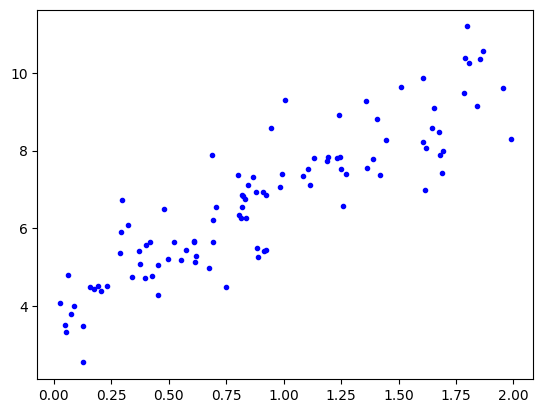

In [23]:
plt.figure()
plt.plot(X,y, "b.")
plt.show()

In [24]:
X_b = np.hstack([X, np.ones((n,1))]) # feature engineering 
X_b

array([[0.37182441, 1.        ],
       [1.19426972, 1.        ],
       [1.44345186, 1.        ],
       [0.91677022, 1.        ],
       [1.79785815, 1.        ],
       [1.23965372, 1.        ],
       [1.51055857, 1.        ],
       [1.85381662, 1.        ],
       [1.65638686, 1.        ],
       [0.02686082, 1.        ],
       [1.61746971, 1.        ],
       [0.32421007, 1.        ],
       [0.98474451, 1.        ],
       [1.13287308, 1.        ],
       [0.45534454, 1.        ],
       [1.24596266, 1.        ],
       [0.49850246, 1.        ],
       [1.64598064, 1.        ],
       [1.6941224 , 1.        ],
       [0.67472188, 1.        ],
       [0.86678922, 1.        ],
       [0.15614443, 1.        ],
       [0.2077074 , 1.        ],
       [0.12827463, 1.        ],
       [0.55332031, 1.        ],
       [1.40651378, 1.        ],
       [0.91153783, 1.        ],
       [0.48192883, 1.        ],
       [1.60806985, 1.        ],
       [0.88469459, 1.        ],
       [0.

$$
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

In [26]:
# w = rng.random((2,1))
w_best  = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
y_pred = X_b @ w # model 
w_best

array([[3.01782918],
       [3.94915909]])

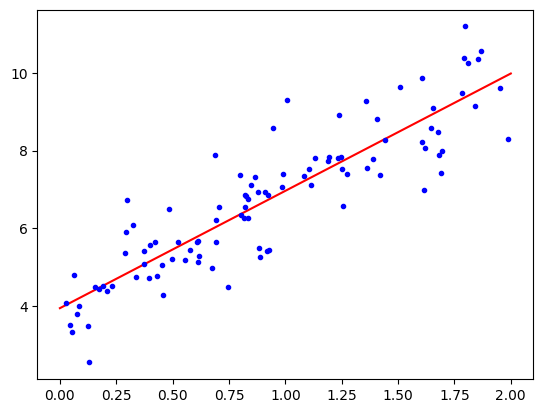

In [27]:
X_new = np.array([[0,1], [2,1]])
# use model equation

y_pred = X_new @ w_best

plt.figure() 
plt.plot(X_new[:,0], y_pred, "r-")
plt.plot(X,y, "b.")
plt.show()


# Batch Gradient Descent

## Loss Funktion 
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


# Gradients
$$\frac{\partial}{\partial m} MSE = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - \hat{y}_i)
$$
$$
\frac{\partial}{\partial b} MSE = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)
$$


# Update
$$
m := m - \eta \cdot \frac{\partial}{\partial m} MSE
$$

$$
b := b - \eta \cdot \frac{\partial}{\partial b} MSE
$$




In [30]:
eta = 0.1 # Lernrate, 0<< eta <1 
epochs = 30 # 1 Mal hat mein ML-Algorithmus den gesamten Datensatz gesehen 

w_bgd = rng.random((2,1))

for epoch in range(epochs): # training loop 
    # gradients 
    gradients = 2 / n * X_b.T @ (X_b @ w_bgd - y )
    # update
    w_bgd = w_bgd - eta*gradients

w_bgd


array([[3.12642971],
       [3.83216028]])

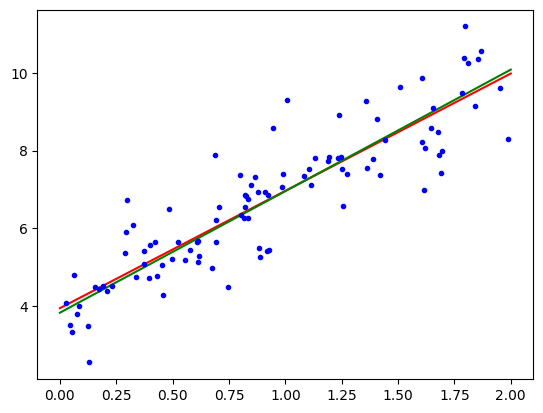

In [31]:
X_new = np.array([[0,1], [2,1]])
# use model equation

y_best = X_new @ w_best
y_bgd = X_new @ w_bgd

plt.figure() 
plt.plot(X_new[:,0], y_pred, "r-")
plt.plot(X_new[:,0], y_bgd, "g-")
plt.plot(X,y, "b.")
plt.show()